In [1]:
import copy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import seaborn as sns
import sys
import time

# custom modules
sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from numba import njit, i8, f8
from src.datafactory import load_lbsn_artefacts, load_util_artefacts, load_aset_artefacts
from src.utils import argnonz, argtopk, haversine

%config InlineBackend.figure_format="retina"
%matplotlib inline

# ---

In [2]:
city = "Florence"  # options available: "Rome", "Florence", "Pisa", "Istanbul", "London"

t_arr = (2, 3, 4, 50)  # partial user feedback
recsys_str_arr = ("pop", "wmf", "bpr", "vae", "lgcn", "ease", "SimpleX", "DiffRec")  # available RecSys
seed_arr = (2025, 2026, 2027, 2028, 2029)  # available seeds
t_coldstart = 10  # cold start threshold

In [3]:
def filter_blob(experiment_t: list[dict], 
                y: np.ndarray, 
                A: np.ndarray, A_sum_bins: list[int], target_cohort: int|None, debug: bool):  # 0-based cohort number
    
    TOUR_MIN_USER_ACTIVITY = 4  # minumum number of interaction required for robust evaluation
    
    assert (
        1
        and target_cohort in {None} | {b for b in range(len(A_sum_bins) + 1)}
        and y.shape == A.shape
    ), "Bad"
    
    out: dict[str,dict|list] = {
        "improvement_user": [],  # more is better
        "improvement_harm": [],  # more is better
        "bias_improvement_user": [],  # 0 is the best
        "bias_improvement_harm": [],  # 0 is the best
    }
    
    selection_mask = y.sum(1) >= TOUR_MIN_USER_ACTIVITY  # for robust evaluation
    
    # do we need some cohort filtering?
    if target_cohort is not None:
        A_sum_aug_bins = [-np.inf] + A_sum_bins + [+np.inf]
        selection_mask = (
            selection_mask &
            (A.sum(1)  > A_sum_aug_bins[target_cohort  ]) & 
            (A.sum(1) <= A_sum_aug_bins[target_cohort+1])
        )
    
    if debug:
        print(f"Selection mask: {selection_mask.sum()} out of {selection_mask.size} | {A.sum(1)[selection_mask].mean():.0f}")

    for record in experiment_t:

        # filter
        caus_user = record["caus_user"][selection_mask]
        nors_user = record["nors_user"][selection_mask]
        data_user = record["data_user"][selection_mask]
        caus_harm = record["caus_harm"][selection_mask]
        nors_harm = record["nors_harm"][selection_mask]
        data_harm = record["data_harm"][selection_mask]

        # uplift & simulation bias
        improvement_user      = np.mean((caus_user - nors_user) / nors_user)
        bias_improvement_user = np.mean((nors_user - data_user) / data_user)
        improvement_harm      = (-1) * (np.sum(caus_harm) - np.sum(nors_harm)) / np.sum(nors_harm)
        bias_improvement_harm = (-1) * (np.sum(nors_harm) - np.sum(data_harm)) / np.sum(data_harm)

        # update
        out["improvement_user"].append(improvement_user)
        out["improvement_harm"].append(improvement_harm)
        out["bias_improvement_user"].append(bias_improvement_user)
        out["bias_improvement_harm"].append(bias_improvement_harm)
    
    return out

In [4]:
def load_experiment(city, recsys_str_arr, t_arr, seed_arr, A_sum_bins=None, target_cohort=None, debug=True):
    
    if debug:
        fig, ax = plt.subplots(1,1, figsize=(6,6))  # All vs. All visualisation
        marker = "o"
        colors = [color for i, color in enumerate(matplotlib.colors.CSS4_COLORS.values()) if i % 10 == 0]

    # for debug
    tau_arr, tau_bias_arr = [], []
    eta_arr, eta_bias_arr = [], []

    # for fine-grained debug
    simulation_lift_dict: dict[(int,str,str,int),any] = {}  # -> (seed,key,recommender_system_key,t)
    simulation_bias_dict: dict[(int,str,str,int),any] = {}
    
    for seed in seed_arr:  # iter over different seeds
        
        y, aset_data_map = load_aset_artefacts(f"../out/{city}_{seed}_aset.hdf5")

        for key in recsys_str_arr:  # iter over different preferences learning algorithms
            
            A = aset_data_map[key]["A"]
            
            for recommender_system_key in recsys_str_arr:  # iter over different recommender systems
                
                with open(f"../out/experiments/runx_{city}_{seed}_{key}_{recommender_system_key}.pk", "rb") as file:
                    experiment = pickle.load(file)
                
                for i, t in enumerate(t_arr):
                    dat = filter_blob(experiment[t]["hist"], 
                                      y=y, 
                                      A=A, A_sum_bins=A_sum_bins, target_cohort=target_cohort, debug=debug)
                    tau, tau_bias = dat["improvement_user"], dat["bias_improvement_user"]  # arr, arr
                    eta, eta_bias = dat["improvement_harm"], dat["bias_improvement_harm"]  # arr, arr

                    # update uplift
                    tau_arr.append(tau)
                    eta_arr.append(eta)
                    # update biases
                    tau_bias_arr.append(tau_bias)
                    eta_bias_arr.append(eta_bias)
                    # update fine-grained uplift and biases dicts
                    simulation_lift_dict[(seed,key,recommender_system_key,t)] = {"user": tau,      "harm": eta}
                    simulation_bias_dict[(seed,key,recommender_system_key,t)] = {"user": tau_bias, "harm": eta_bias}
                    
                    if debug:
                        ax.plot(  # -> All vs. All (just for sanity check)
                            tau,
                            eta,
                            marker=marker, color=colors[i], ms=4, ls="none", alpha=0.9, mfc="none", label=f"t={t}")
    
    if debug:
        # data flatten
        tau_flatten_arr = np.array(tau_arr).ravel()
        eta_flatten_arr = np.array(eta_arr).ravel()

        # bias flatten
        tau_bias_flatten_arr = np.array(tau_bias_arr).ravel()
        eta_bias_flatten_arr = np.array(eta_bias_arr).ravel()

        # average uplift over (seed,key,recommender_system_key,t) | lambda
        average_tau_arr = np.mean(tau_arr, axis=0)
        average_eta_arr = np.mean(eta_arr, axis=0)

        ax.plot(
            average_tau_arr,
            average_eta_arr,
            marker=marker, color="k", ms=4, ls="-", lw=4, alpha=1.0, 
            markerfacecolor="none")

        ax.axhline(0, color="k", ls="--")
        ax.axvline(0, color="k", ls="--")
        ax.set_xlabel("User uplift, (Urs - Unors) / Unors")
        ax.set_ylabel("Dest uplift, (Vrs - Vnors) / Vnors")
        fig.show()
    
    return simulation_lift_dict, simulation_bias_dict

# ---

In [5]:
simulation_lift_dict, simulation_bias_dict = load_experiment(
    city, 
    recsys_str_arr, 
    t_arr, 
    seed_arr, 
    A_sum_bins=[], 
    target_cohort=None, 
    debug=False, 
)

Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Florence_2025_aset.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Florence_2026_aset.hdf5
Processing data storage with key [DiffRec]

# ---

pop     :  u= 40.89(2.64)  h= -2.43(0.22)  sum= 43.32 [%]  latex=  &40.9(2.6) & -2.4(0.2)
wmf     :  u= 12.50(6.83)  h= -4.62(0.63)  sum= 17.13 [%]  latex=  &12.5(6.8) & -4.6(0.6)
bpr     :  u=  4.00(0.28)  h= -5.68(0.24)  sum=  9.67 [%]  latex=  & 4.0(0.3) & -5.7(0.2)
vae     :  u= 29.78(3.91)  h= -2.26(0.26)  sum= 32.04 [%]  latex=  &29.8(3.9) & -2.3(0.3)
lgcn    :  u=  9.64(0.37)  h= -3.55(0.22)  sum= 13.19 [%]  latex=  & 9.6(0.4) & -3.6(0.2)
ease    :  u= 20.32(0.89)  h= -2.00(0.25)  sum= 22.31 [%]  latex=  &20.3(0.9) & -2.0(0.2)
SimpleX :  u= 22.01(9.91)  h= -2.20(0.83)  sum= 24.21 [%]  latex=  &22.0(9.9) & -2.2(0.8)
DiffRec :  u= 10.73(4.56)  h= -3.66(0.80)  sum= 14.39 [%]  latex=  &10.7(4.6) & -3.7(0.8)
BEST KEY=bpr


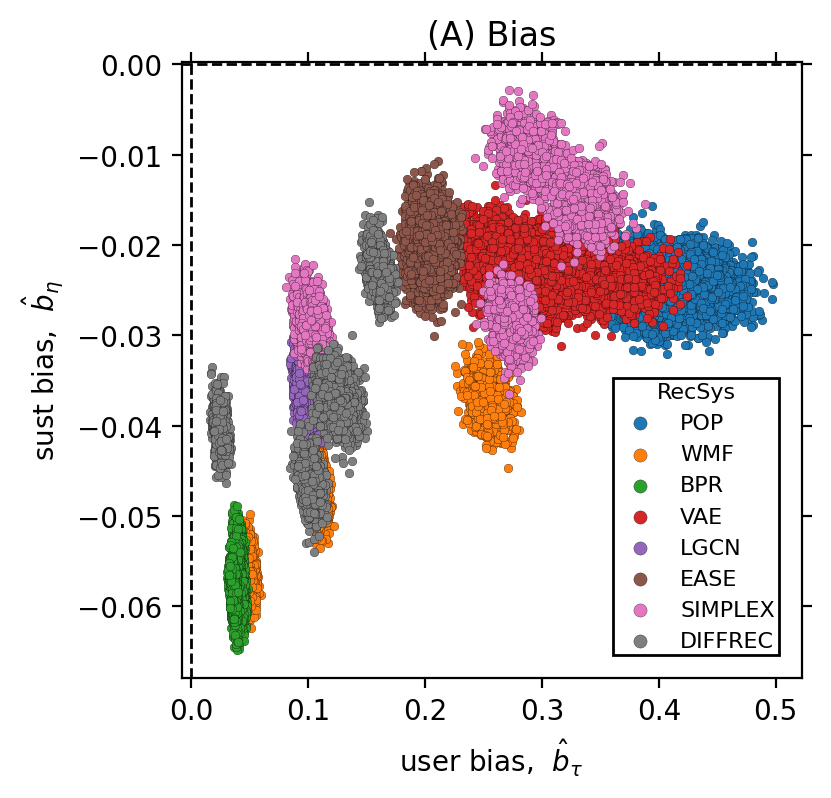

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4,4))

colors = ["r", "g", "b", "y", "m", "c", "pink", "orange"]

# analysis of bias, averaged over (seed,recommender_system_key,t,lambda) | key
flat_simulation_bias_dict: dict[str,dict[str,any]] = {}

for (seed, key, recommender_system_key, t), dict_ in simulation_bias_dict.items():
    if t > t_coldstart:
        continue
    dref = flat_simulation_bias_dict.setdefault(
        key, {"user": [], "harm": []})
    dref["user"].extend(dict_["user"])
    dref["harm"].extend(dict_["harm"])


BEST_KEY = "NULL"
best_sum = 100000
for key in flat_simulation_bias_dict:
    coef = 100  # -> [%]
    # >>>
    user_v_arr = np.array(flat_simulation_bias_dict[key]["user"])
    harm_v_arr = np.array(flat_simulation_bias_dict[key]["harm"])
    # >>>
    user_b, user_b_sd = np.mean(coef * user_v_arr), np.std(coef * user_v_arr)
    harm_b, harm_b_sd = np.mean(coef * harm_v_arr), np.std(coef * harm_v_arr)
    total = np.abs(user_b) + np.abs(harm_b)
    print(f"{key:<7} :  "
          f"u={user_b: 6.2f}({user_b_sd:.2f})  "
          f"h={harm_b: 6.2f}({harm_b_sd:.2f})  sum={total:6.2f} [%]  "
          f"latex=  &{user_b:>4.1f}({user_b_sd:.1f}) & {harm_b:>4.1f}({harm_b_sd:.1f})")
    
    ax.scatter(user_v_arr, 
               harm_v_arr, s=10, label=key.upper(), lw=0.1, alpha=1.0, marker="o", edgecolor="k")
    
    if (total < best_sum) and (key != "pop"):
        BEST_KEY = key
        best_sum = total

del user_b, user_b_sd, user_v_arr
del harm_b, harm_b_sd, harm_v_arr

# vis
ax.tick_params(axis="both", which="both", bottom=1, top=1, left=1, right=1)

ax.set_xlabel(r"user bias,  $\hat{b}_{\tau}$")
ax.set_ylabel(r"sust bias,  $\hat{b}_{\eta}$")

ax.set_title(r"(A) Bias")
ax.axhline(0, color="k", ls="--", lw=1.0)
ax.axvline(0, color="k", ls="--", lw=1.0)
ax.legend(loc="lower right", title=r"RecSys", fontsize=8, title_fontsize=8, framealpha=1.0,
          markerscale=1.5, borderaxespad=1, frameon=1, fancybox=0,
          shadow=0, edgecolor="k", borderpad=0.2)
fig.show()
print(f"BEST KEY={BEST_KEY}")

In [7]:
bb = []  # beta
gg = []  # gamma
kk = []  # kappa

for seed in seed_arr:
    # load
    _, A_map = load_aset_artefacts(f"../out/{city}_{seed}_aset.hdf5")
    # populate
    bb.append(A_map[BEST_KEY]["beta" ])
    gg.append(A_map[BEST_KEY]["gamma"])
    kk.append(A_map[BEST_KEY]["u_thr"])
    print(f"A:", np.quantile(A_map[BEST_KEY]["A"].sum(1), q=[0.05, 0.25, 0.5, 0.75, 0.95]))

bb = np.hstack(bb)
gg = np.hstack(gg)
kk = np.hstack(kk)
city, BEST_KEY

Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Florence_2025_aset.hdf5
A: [ 8. 11. 15. 19. 30.]
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Florence_2026_aset.hdf5
A: [ 8. 12. 14. 1

('Florence', 'bpr')

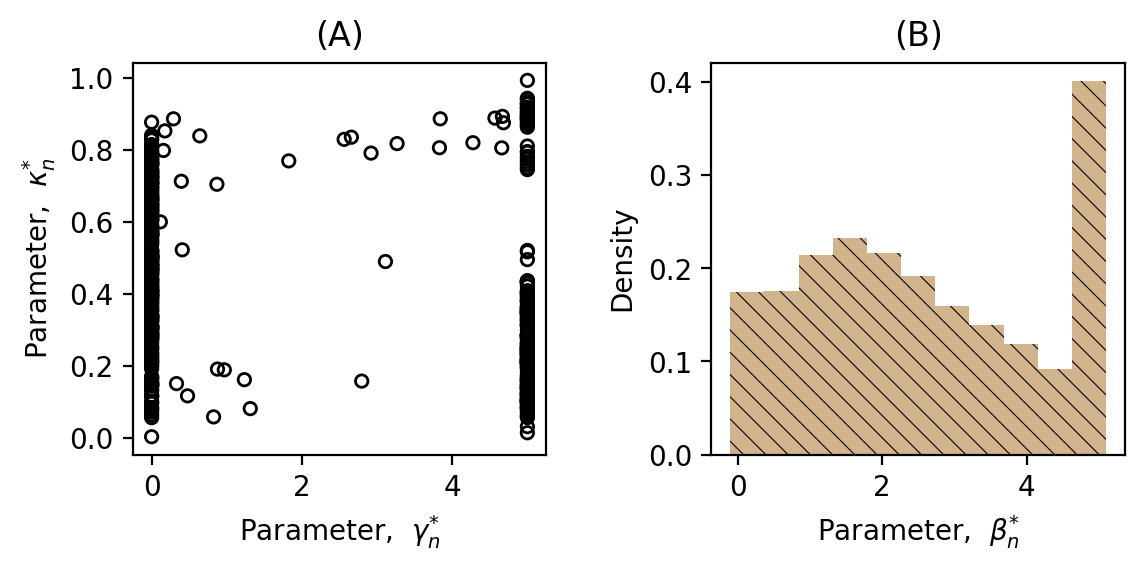

In [8]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(6.2,2.8))

fig.subplots_adjust(left=0.1,
                    bottom=0.2,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.1,
)

_min = 0.0 - 0.1
_max = 5.0 + 0.1
h = max(1, int(len(bb) / 500))

ax.scatter(gg[::h], kk[::h], ec="k", fc="none", s=20, marker="o")
ax.set_xlabel(r"Parameter,  $\gamma_n^{*}$")
ax.set_ylabel(r"Parameter,  $\kappa_n^{*}$")

# olivedrab
bx.hist(bb, bins=11, range=(_min, _max), density=True, histtype="bar", color="tan", alpha=1.0, 
        ec="k", lw=1.0, hatch="\\\\\\", hatch_linewidth=0.4)
bx.set_xlabel(r"Parameter,  $\beta_n^{*}$")  #  \cdot \max_j(u_{nj}^{*})
bx.set_ylabel("Density")

ax.minorticks_off()
bx.minorticks_off()

ax.set_title(r"(A)")
bx.set_title(r"(B)")

fig.savefig(f"{city}_param_results.svg", dpi=300, pad_inches=0.1)
fig.show()

# ---

In [9]:
with open(f"../out/experiments/runx_{city}_{seed}_{BEST_KEY}_{BEST_KEY}.pk", "rb") as file:
    experiment = pickle.load(file)


_any_ind = 3
lamb_arr, croi = experiment[_any_ind]["args"]["lamb_arr"], experiment[_any_ind]["args"]["croi"]
lamb_arr

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ])

In [10]:
# this parameter defines the algorithm (key) that achieves the least bias in
# both dimensions: (tau_bias, eta_bias)
# the least bias guaranties the most trustworthy simulation results

lift_rec_t: dict[int,tuple[any,any]] = {t: ([], []) for t in t_arr}
lift_pop_t: dict[int,tuple[any,any]] = {t: ([], []) for t in t_arr}

for (seed, key, recommender_system_key, t), arr in simulation_lift_dict.items():
    if key == BEST_KEY:
        if recommender_system_key == "pop":
            lift_pop_t[t][0].append(arr["user"])
            lift_pop_t[t][1].append(arr["harm"])
        else:
            lift_rec_t[t][0].append(arr["user"])
            lift_rec_t[t][1].append(arr["harm"])

del seed, key, recommender_system_key, t

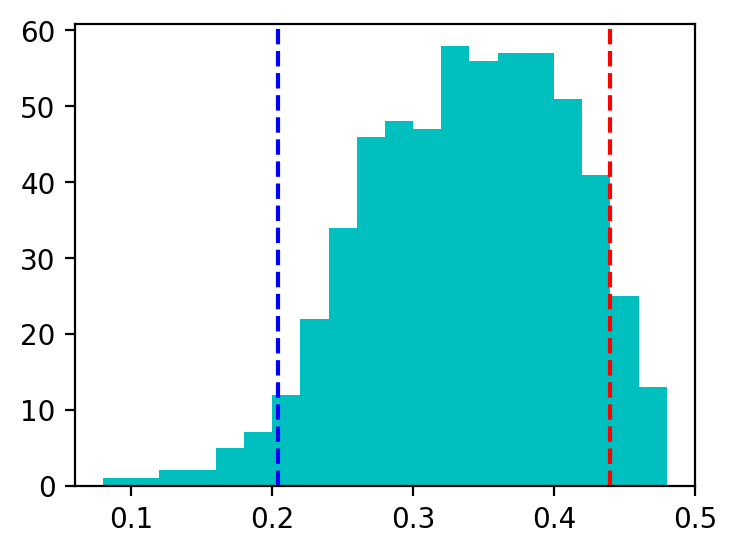

lamb_min=0.2040
lamb_max=0.4400


In [11]:
out = []

for t in t_arr:
    if t > t_coldstart:
        continue
    for tau_arr, eta_arr in zip(
        lift_rec_t[t][0], 
        lift_rec_t[t][1],
    ):
        assert len(lamb_arr) == len(tau_arr), "Shape mismatch"
        assert len(lamb_arr) == len(eta_arr), "Shape mismatch"
        for lamb, tau, eta in zip(lamb_arr, tau_arr, eta_arr):
            if (tau >= 0) and (eta >= 0):
                out.append(lamb)

if out:
    lamb_min = np.quantile(out, q=0.05)
    lamb_max = np.quantile(out, q=0.95)
else:
    lamb_min = 0
    lamb_max = 1

fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.hist(out, bins=20, color="c", ec="k")
ax.axvline(lamb_min, c="b", ls="--")
ax.axvline(lamb_max, c="r", ls="--")
plt.show()
print(f"lamb_min={lamb_min:.4f}")
print(f"lamb_max={lamb_max:.4f}")

# ---

In [12]:
class Fmt(matplotlib.ticker.ScalarFormatter):
    def _set_format(self):  # Override function that finds format to use.
        self.format = "%1.1f"  # Give format here

yfmt = Fmt()

In [13]:
def integrate_trapezoidal(x, y, ptr0=0.1):
    assert len(x) == len(y), "Shape mismatch!"
    x_arr = []
    s_arr = []
    n = len(x)
    i = 0
    ptr_curr = ptr0
    h = 0.00035
    while (ptr_curr > 0) and (i < n):
        while (i < n-1) and (x[i] > ptr_curr):
            i += 1
        x_arr.append( ptr_curr )
        s_arr.append( np.maximum(0.0, (y[i])*h) )
        ptr_curr -= h
    
    x_ = x_arr
    s_ = np.cumsum(s_arr)
    
    return x_, s_

In [14]:
mapper = {
    "wmf"    : "MF",
    "bpr"    : "BPR",
    "vae"    : "VAE",
    "lgcn"   : "LightGCN",
    "ease"   : "EASE",
    "SimpleX": "Simplex",
    "DiffRec": "DiffRec",
}

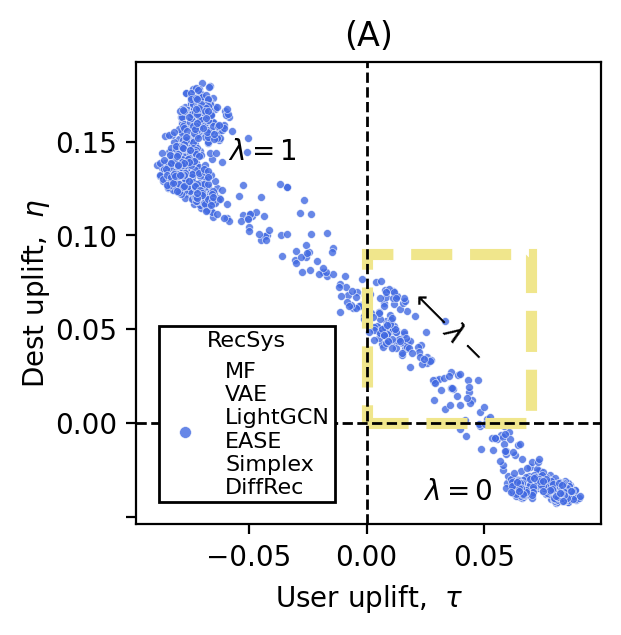

In [15]:
fig, ax = plt.subplots(1,1, figsize=(3, 3))

# >>>

my_tau = []
my_eta = []
for t, (tau_arr, eta_arr) in lift_rec_t.items():  # REC or POP
    if t > t_coldstart:
        continue
    my_tau.extend(tau_arr)
    my_eta.extend(eta_arr)

flat_tau = np.array(my_tau).ravel()[::4]
flat_eta = np.array(my_eta).ravel()[::4]

h = sns.scatterplot(
    x=flat_tau,
    y=flat_eta,
    marker="o", s=8, color="royalblue", alpha=0.8, ec="w", ax=ax, legend=False, 
    label="\n".join((mapper[k] for k in mapper 
                     if k not in (BEST_KEY, "pop"))),
)
h.legend(loc="lower left", title="RecSys", fontsize=8, title_fontsize=8,
         markerscale=1.5, borderaxespad=1, frameon=1, fancybox=0, shadow=0, edgecolor="k", borderpad=0.2)
h.axvline(x=0, color="k", ls="--", lw=1.0)
h.axhline(y=0, color="k", ls="--", lw=1.0)
sns.despine(ax=h, top=False, right=False, left=False, bottom=False)

# h.plot(  # -> ALL ALG w/o BEST_KEY
#     np.mean(my_tau, axis=0),
#     np.mean(my_eta, axis=0),
#     marker="o", color="k", ms=4, ls="--", lw=1.2, alpha=1.0, label="Avg", mec="k", mfc="none")

# h.set_xlabel(r"User uplift,  $(1/N) \, \Sigma_{n=1}^N (s_n^{R} - s_n^{0}) / s_n^{0}$")
# h.set_ylabel(r"Dest uplift,  $- (h^{R}-h^{0}) / h^{0}$", labelpad=+1)

h.set_xlabel(r"User uplift,  $\tau$")
h.set_ylabel(r"Dest uplift,  $\eta$", labelpad=+1)
h.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%.2f"))

def hide_negative_ticks(x, pos):
    return f"{x:.2f}" if x >= 0 else ""

h.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(hide_negative_ticks))
h.minorticks_off()

h.legend(loc="lower left", title="RecSys", fontsize=8, title_fontsize=8, framealpha=1.0,
         markerscale=1.5, borderaxespad=1, frameon=1, fancybox=0, shadow=0, edgecolor="k", borderpad=0.2)

h.set_title(r"(A)")

# >>>

match city:
    
    case "Rome":
        # create a Rectangle patch
        rect = matplotlib.patches.Rectangle((0.000, 0.000), 0.07, 0.07, linewidth=4, 
                                            edgecolor="khaki", 
                                            facecolor="none", ls="--")
        
#         h.text( 0.034, -0.025, s=r"$\lambda=0$", color="k", fontsize=10, fontstyle="italic")
#         h.text(-0.059,  0.140, s=r"$\lambda=1$", color="k", fontsize=10, fontstyle="italic")
#         h.text(x=+0.015, y=0.032,
#                s=r"$\longleftarrow{\lambda}-$", rotation=-45)  # x
    
    case "Florence":
        # create a Rectangle patch
        rect = matplotlib.patches.Rectangle((0.000, 0.000), 0.07, 0.09, linewidth=4, 
                                            edgecolor="khaki", 
                                            facecolor="none", ls="--")
        h.text( 0.024, -0.041, s=r"$\lambda=0$", color="k", fontsize=10, fontstyle="italic")
        h.text(-0.059,  0.140, s=r"$\lambda=1$", color="k", fontsize=10, fontstyle="italic")
        h.text(x=+0.015, y=0.032,
               s=r"$\longleftarrow{\lambda}-$", rotation=-45)  # x

    case "Pisa":
        # create a Rectangle patch
        rect = matplotlib.patches.Rectangle((0.000, 0.000), 0.07, 0.12, linewidth=4, 
                                            edgecolor="khaki", 
                                            facecolor="none", ls="--")
    
    case "Istanbul":
        # create a Rectangle patch
        rect = matplotlib.patches.Rectangle((0.000, 0.000), 0.05, 0.07, linewidth=4, 
                                            edgecolor="khaki", 
                                            facecolor="none", ls="--")
    
    case "London":
        # create a Rectangle patch
        rect = matplotlib.patches.Rectangle((0.000, 0.000), 0.11, 0.18, linewidth=4, 
                                            edgecolor="khaki", 
                                            facecolor="none", ls="--")

# add the patch to the Axes
h.add_patch(rect)

fig.savefig(f"{city}_results.svg", dpi=300, pad_inches=0.1, bbox_inches="tight")
fig.show()

# --- Uplift Analysis

In [16]:
tau_eta0 = []
eta_tau0 = []

d_tau_pct = 0.020 * (np.quantile(flat_tau, 0.95) - np.quantile(flat_tau, 0.05))
d_eta_pct = 0.020 * (np.quantile(flat_eta, 0.95) - np.quantile(flat_eta, 0.05))

for tau, eta in zip(flat_tau, flat_eta):
    
    if (eta > -d_eta_pct) & (eta < d_eta_pct):
        tau_eta0.append(tau)
    if (tau > -d_tau_pct) & (tau < d_tau_pct):
        eta_tau0.append(eta)

print(f"tot")
print(f"tau|eta=0 = {np.mean(tau_eta0):>5.3f} +/- {np.std(tau_eta0):.3f}  len={len(tau_eta0)}\n"
      f"eta|tau=0 = {np.mean(eta_tau0):>5.3f} +/- {np.std(eta_tau0):.3f}  len={len(eta_tau0)}\n")
print(d_tau_pct, d_eta_pct)

tot
tau|eta=0 = 0.050 +/- 0.006  len=9
eta|tau=0 = 0.059 +/- 0.008  len=17

0.003341287970542908 0.004118644336176013


In [17]:
tau_eta0 = []
eta_tau0 = []

for t in t_arr:
    for tau_arr, eta_arr in zip(  # -> avarege over recsys (only `pop` in this case)
        lift_pop_t[t][0],
        lift_pop_t[t][1]
    ):
        for tau, eta in zip(tau_arr, eta_arr):
            if (eta > -d_eta_pct) & (eta < d_eta_pct):
                tau_eta0.append(tau)
            if (tau > -d_tau_pct) & (tau < d_tau_pct):
                eta_tau0.append(eta)

print(f"pop")
print(f"tau|eta=0 = {np.mean(tau_eta0):>5.2f} +/- {np.std(tau_eta0):.2f}  len={len(tau_eta0)}\n"
      f"eta|tau=0 = {np.mean(eta_tau0):>5.2f} +/- {np.std(eta_tau0):.2f}  len={len(eta_tau0)}\n")

del tau_arr, eta_arr, tau_eta0, eta_tau0

# -----------------------------------------------------------------

print(f"---\n")

for t in t_arr:
    tau_eta0 = []
    eta_tau0 = []
    for tau_arr, eta_arr in zip(  # -> avarege over recsys | t
        lift_rec_t[t][0],
        lift_rec_t[t][1]
    ):
        for tau, eta in zip(tau_arr, eta_arr):
            if (eta > -d_eta_pct) & (eta < d_eta_pct):
                tau_eta0.append(tau)
            if (tau > -d_tau_pct) & (tau < d_tau_pct):
                eta_tau0.append(eta)
    print(f"t={t}")
    print(f"tau|eta=0 = {np.mean(tau_eta0):>5.2f} +/- {np.std(tau_eta0):.2f}  len={len(tau_eta0)}\n"
          f"eta|tau=0 = {np.mean(eta_tau0):>5.2f} +/- {np.std(eta_tau0):.2f}  len={len(eta_tau0)}\n")
    
    del tau_arr, eta_arr, tau_eta0, eta_tau0

pop
tau|eta=0 =  0.05 +/- 0.00  len=6
eta|tau=0 =  0.05 +/- 0.00  len=7

---

t=2
tau|eta=0 =  0.05 +/- 0.01  len=15
eta|tau=0 =  0.06 +/- 0.01  len=22

t=3
tau|eta=0 =  0.05 +/- 0.00  len=6
eta|tau=0 =  0.06 +/- 0.01  len=20

t=4
tau|eta=0 =  0.05 +/- 0.00  len=8
eta|tau=0 =  0.06 +/- 0.01  len=18

t=50
tau|eta=0 =  0.06 +/- 0.01  len=21
eta|tau=0 =  0.08 +/- 0.02  len=17



# --- Clustering

In [18]:
best_key_dict = {"Rome": "SimpleX", "Florence": "bpr", "Pisa": "bpr", "Istanbul": "bpr", "London": "lgcn"}

In [19]:
#     50% 80%
# R: [15. 21.]
# F: [15. 20.]
# P: [ 9. 12.]
# I: [10. 13.]
# L: [ 9. 11.]
A_sum_bins_dict = {"Rome": [15,21], "Florence": [15,20], "Pisa": [9,12], "Istanbul": [10,13], "London": [9,11]}

Loaded successfully lbsn artefacts <== Rome_lbsn.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Processing data storage with key [y      ]... DONE.
Loaded successfully reco artefacts <== Rome_2025_util.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loa

Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Rome_2029_aset.hdf5
tot
tau|eta=0 =  0.016, 0.012  len=154
eta|tau=0 =  0.027, 0.013  len=175

pop
tau|eta=0 =  0.017, 0.011  len=8
eta|tau=0 =  0.034, 0.010  len=9

Loaded successfully lbsn artefacts <== Florence_lbsn.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Processing data storage with key [y      ]... DONE.
Loaded successfully reco artefacts <== Florence_2025_util.hdf5
Processing data storage with key [DiffRec]... DONE

Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Florence_2028_aset.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Florence_2029_aset.hdf5
tot
tau|eta=0 =  0.032, 0.006  len=71
eta|tau=0 =  0.047, 0.012  len=134

pop
tau|eta=0 =  0.032, 0.005  len=7
eta|tau=0 =  0.042, 0.010  len=7

Loaded successfully lbsn artefacts <== Pisa_lbsn.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.

Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Pisa_2028_aset.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Pisa_2029_aset.hdf5
tot
tau|eta=0 =  0.033, 0.017  len=205
eta|tau=0 =

Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Istanbul_2026_aset.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== Istanbul_2027_aset.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]

Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== London_2026_aset.hdf5
Processing data storage with key [DiffRec]... DONE.
Processing data storage with key [SimpleX]... DONE.
Processing data storage with key [bpr    ]... DONE.
Processing data storage with key [ease   ]... DONE.
Processing data storage with key [lgcn   ]... DONE.
Processing data storage with key [pop    ]... DONE.
Processing data storage with key [vae    ]... DONE.
Processing data storage with key [wmf    ]... DONE.
Loaded successfully aset artefacts <== London_2027_aset.hdf5
Processing data storage with key [DiffRec]... 

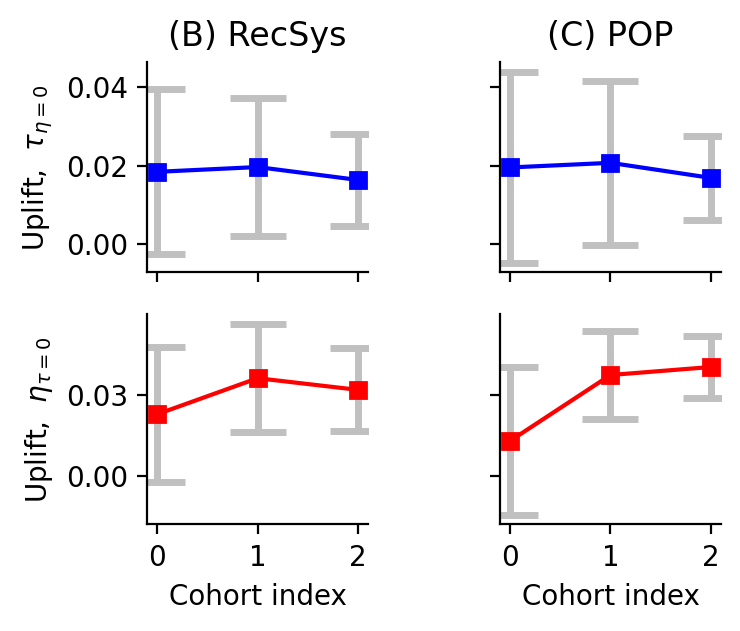

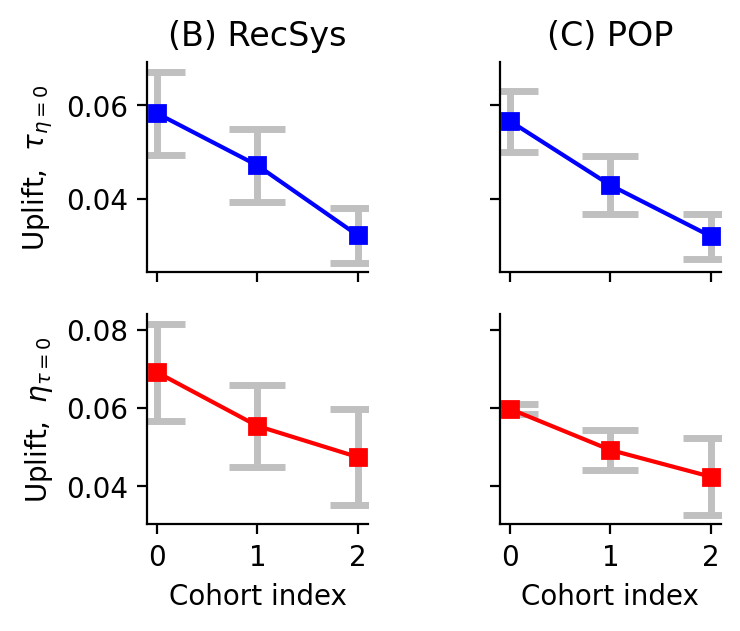

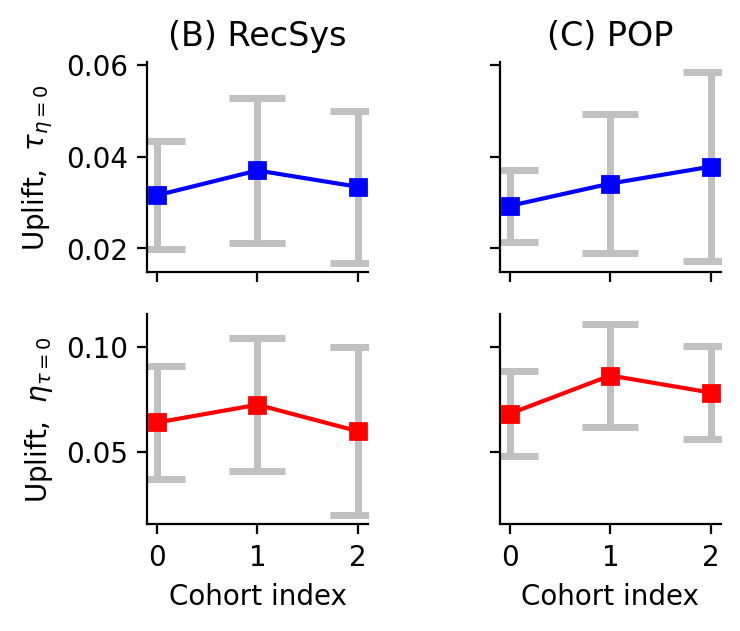

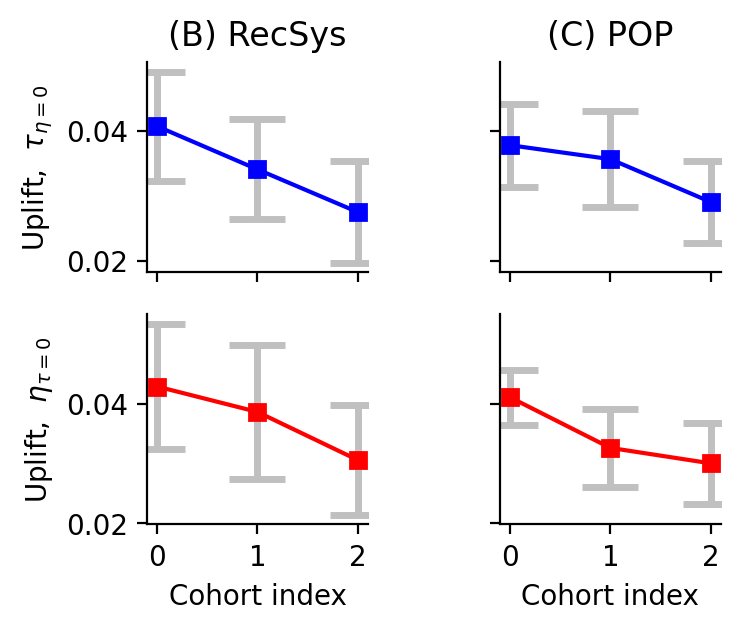

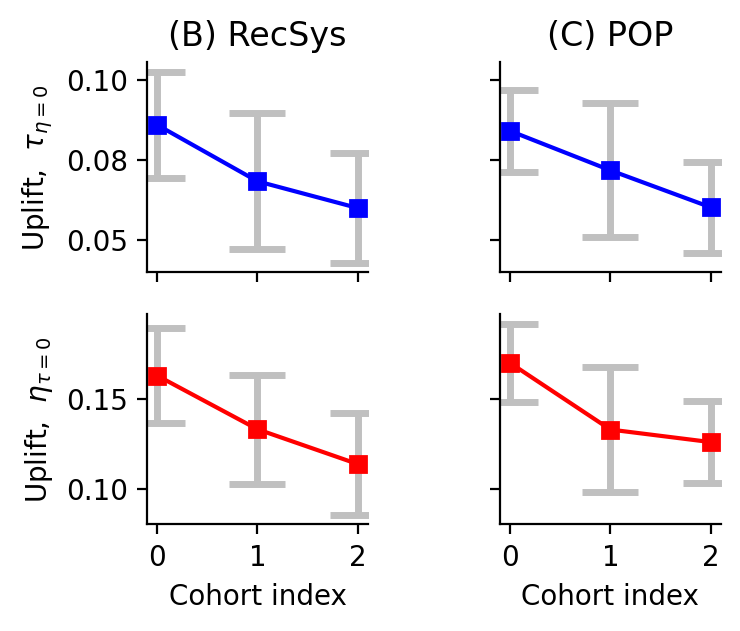

In [20]:
SELECTED_SEED = 2025
UPLIFTED_SENSITIVITY_OFFSET = 0.04
cohorts = np.array([0,1,2])
xcolors = ["tan","cadetblue","dimgray","red"]


stats = {}
for city in best_key_dict:
    
    # #################################################################
    
    stats[city] = {}

    lbsn_file = f"../out/{city}_lbsn.hdf5"
    util_file = f"../out/{city}_{SELECTED_SEED}_util.hdf5"
    aset_file = f"../out/{city}_{SELECTED_SEED}_aset.hdf5"

    y, t, f, fnames, envstruct = load_lbsn_artefacts(lbsn_file)

    city_centre = envstruct["city_centre"]
    city_radius = envstruct["city_radius"]
    size = y.shape[1]
    croi = []
    for j in range(size):
        if (haversine(city_centre, envstruct["location"][j,:]) < 0.2*city_radius) or (j < 0.2*size):
            croi += [j]
    croi = np.array(croi, dtype="i8")

    true_data_map, _ = load_util_artefacts(util_file)
    _, aset_data_map = load_aset_artefacts(aset_file)

    y = true_data_map["y"]
    u = true_data_map[best_key_dict[city]]
    A = aset_data_map[best_key_dict[city]]["A"]
    
    assert (
        1
        and y.shape == A.shape
        and y.shape == u.shape
    ), "Bad"
    
    print(np.quantile(A.sum(1), q=[0.25, 0.5, 0.75]))
    print(np.quantile(A.sum(1), q=[0.33, 0.5, 0.66]))
    print(np.quantile(A.sum(1), q=[0.50, 0.8]))
    
    N = len(y)
    J = len(f)
    N, J
    
    # #################################################################

    for target_cohort in cohorts:

        stats[city][f"cohort={target_cohort}"] = {
            "tot": {},
            "pop": {},
        }

        print(f"\n\nProcessing cohort {target_cohort}")

        simulation_lift_dict, simulation_bias_dict = load_experiment(
            city, recsys_str_arr, (2,3,4), [2025,2026,2027,2028,2029], A_sum_bins=A_sum_bins_dict[city], 
            target_cohort=target_cohort, debug=False)

        # this parameter defines the algorithm (key) that achieves the least bias in
        # both dimensions: (tau_bias, eta_bias)
        # the least bias guaranties the most trustworthy simulation results

        lift_rec_t: dict[int,tuple[any,any]] = {t: ([], []) for t in t_arr}
        lift_pop_t: dict[int,tuple[any,any]] = {t: ([], []) for t in t_arr}

        for (seed, key, recommender_system_key, t), arr in simulation_lift_dict.items():
            if key == best_key_dict[city]:  #  and seed == SELECTED_SEED
                if recommender_system_key == "pop":
                    lift_pop_t[t][0].append(arr["user"])
                    lift_pop_t[t][1].append(arr["harm"])
                else:
                    lift_rec_t[t][0].append(arr["user"])
                    lift_rec_t[t][1].append(arr["harm"])

        del seed, key, recommender_system_key, t

        # -----------------------------------------------------------------

        my_tau = []
        my_eta = []
        for t, (tau_arr, eta_arr) in lift_rec_t.items():
            if t > t_coldstart:
                continue
            my_tau.extend(tau_arr)
            my_eta.extend(eta_arr)

        flat_tau = np.array(my_tau).ravel()
        flat_eta = np.array(my_eta).ravel()

        d_tau_pct = UPLIFTED_SENSITIVITY_OFFSET * (np.quantile(flat_tau, 0.95) - np.quantile(flat_tau, 0.05))
        d_eta_pct = UPLIFTED_SENSITIVITY_OFFSET * (np.quantile(flat_eta, 0.95) - np.quantile(flat_eta, 0.05))

        # -----------------------------------------------------------------

        tau_eta0 = []
        eta_tau0 = []

        for t in t_arr:
            if t > t_coldstart:
                continue
            for tau_arr, eta_arr in zip(  # -> avarege over recsys
                lift_rec_t[t][0],
                lift_rec_t[t][1]
            ):
                for tau, eta in zip(tau_arr, eta_arr):
                    if (eta > -d_eta_pct) & (eta < d_eta_pct):
                        tau_eta0.append(tau)
                    if (tau > -d_tau_pct) & (tau < d_tau_pct):
                        eta_tau0.append(eta)

        print(f"tot")
        print(f"tau|eta=0 = {np.mean(tau_eta0):>6.3f}, {np.std(tau_eta0):.3f}  len={len(tau_eta0)}\n"
              f"eta|tau=0 = {np.mean(eta_tau0):>6.3f}, {np.std(eta_tau0):.3f}  len={len(eta_tau0)}\n")

        stats[city][f"cohort={target_cohort}"]["tot"]["tau|eta=0"] = (np.mean(tau_eta0), np.std(tau_eta0))
        stats[city][f"cohort={target_cohort}"]["tot"]["eta|tau=0"] = (np.mean(eta_tau0), np.std(eta_tau0))

        del tau_arr, eta_arr, tau_eta0, eta_tau0

        # -----------------------------------------------------------------

        tau_eta0 = []
        eta_tau0 = []

        for t in t_arr:
            for tau_arr, eta_arr in zip(  # -> avarege over recsys (only `pop` in this case)
                lift_pop_t[t][0],
                lift_pop_t[t][1]
            ):
                for tau, eta in zip(tau_arr, eta_arr):
                    if (eta > -d_eta_pct) & (eta < d_eta_pct):
                        tau_eta0.append(tau)
                    if (tau > -d_tau_pct) & (tau < d_tau_pct):
                        eta_tau0.append(eta)

        print(f"pop")
        print(f"tau|eta=0 = {np.mean(tau_eta0):>6.3f}, {np.std(tau_eta0):.3f}  len={len(tau_eta0)}\n"
              f"eta|tau=0 = {np.mean(eta_tau0):>6.3f}, {np.std(eta_tau0):.3f}  len={len(eta_tau0)}\n")

        stats[city][f"cohort={target_cohort}"]["pop"]["tau|eta=0"] = (np.mean(tau_eta0), np.std(tau_eta0))
        stats[city][f"cohort={target_cohort}"]["pop"]["eta|tau=0"] = (np.mean(eta_tau0), np.std(eta_tau0))

        del tau_arr, eta_arr, tau_eta0, eta_tau0
    
    
    # #################################################################

    fig = plt.figure(figsize=(3.7,3.0))  # total figure size

    # Outer GridSpec: 1 row, 2 columns — first column is large (for yx), second for ax+bx
    outer = gridspec.GridSpec(1, 1, wspace=0.5, hspace=0.2)  # width_ratios=[2,2], 

    # SubGridSpec: split second column into 2 plots (ax and bx), with small spacing
    # inner_l = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer[0], wspace=0.4, hspace=0)

    # SubGridSpec: split second column into 2 plots (ax and bx), with small spacing
    inner_r = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0], wspace=0.6, hspace=0.2)

    # Create subplots
    # ax cx
    # bx dx
    # yx = fig.add_subplot(inner_l[0])
    ax = fig.add_subplot(inner_r[0,0])
    bx = fig.add_subplot(inner_r[1,0])
    cx = fig.add_subplot(inner_r[0,1], sharey=ax)
    dx = fig.add_subplot(inner_r[1,1], sharey=bx)

    cx.yaxis.set_tick_params(labelleft=False)
    dx.yaxis.set_tick_params(labelleft=False)

    tot_taueta0_mu = [stats[city][f"cohort={i}"]["tot"]["tau|eta=0"][0] for i in cohorts]
    tot_taueta0_sd = [stats[city][f"cohort={i}"]["tot"]["tau|eta=0"][1] for i in cohorts]
    pop_taueta0_mu = [stats[city][f"cohort={i}"]["pop"]["tau|eta=0"][0] for i in cohorts]
    pop_taueta0_sd = [stats[city][f"cohort={i}"]["pop"]["tau|eta=0"][1] for i in cohorts]

    tot_etatau0_mu = [stats[city][f"cohort={i}"]["tot"]["eta|tau=0"][0] for i in cohorts]
    tot_etatau0_sd = [stats[city][f"cohort={i}"]["tot"]["eta|tau=0"][1] for i in cohorts]
    pop_etatau0_mu = [stats[city][f"cohort={i}"]["pop"]["eta|tau=0"][0] for i in cohorts]
    pop_etatau0_sd = [stats[city][f"cohort={i}"]["pop"]["eta|tau=0"][1] for i in cohorts]

    # >>>

    ecolor = "silver"


    ax.errorbar(
        cohorts, tot_taueta0_mu, yerr=tot_taueta0_sd, fmt="-s", capsize=10, capthick=2.5, 
        ecolor=ecolor, elinewidth=2.5, lw=1.5, color="b", 
    )

    bx.errorbar(
        cohorts, tot_etatau0_mu, yerr=tot_etatau0_sd, fmt="-s", capsize=10, capthick=2.5, 
        ecolor=ecolor, elinewidth=2.5, lw=1.5, color="r", 
    )

    # >>>

    cx.errorbar(
        cohorts, pop_taueta0_mu, yerr=pop_taueta0_sd, fmt="-s", capsize=10, capthick=2.5, 
        ecolor=ecolor, elinewidth=2.5, lw=1.5, color="b", 
    )

    dx.errorbar(
        cohorts, pop_etatau0_mu, yerr=pop_etatau0_sd, fmt="-s", capsize=10, capthick=2.5, 
        ecolor=ecolor, elinewidth=2.5, lw=1.5, color="r", 
    )

    _hhh = max(1, int(len(y) / 900))

    ax.set_xticks(cohorts, [])
    bx.set_xticks(cohorts)
    cx.set_xticks(cohorts, [])
    dx.set_xticks(cohorts)

    ax.minorticks_off()
    bx.minorticks_off()
    cx.minorticks_off()
    dx.minorticks_off()

    ax.set_title("(B) RecSys")
    cx.set_title("(C) POP")

    ax.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%.2f"))
    bx.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%.2f"))

    ax.set_ylabel(r"Uplift,  $\tau_{\eta=0}$")
    bx.set_ylabel(r"Uplift,  $\eta_{\tau=0}$")
    bx.set_xlabel("Cohort index")
    dx.set_xlabel("Cohort index")

    for xx in [ax, bx, cx, dx]:
        xx.spines["right"].set_visible(False)
        xx.spines["top"].set_visible(False)
        xx.tick_params(top=False, right=False)

    # -----------------------------------------------------------------

    fig.savefig(f"{city}_bar_results.svg", dpi=300, pad_inches=0.1, bbox_inches="tight")
    fig.show()

# --- Recommendation Policy in Action

In [25]:
with open(f"../out/experiments/runx_{'Florence'}_{2025}_{BEST_KEY}_{'DiffRec'}.pk", "rb") as file:
    experiment = pickle.load(file)
    experiment = experiment[3]  # -> particular t=3

hist = experiment["hist"]
best_ind = 0
lamb_max = 0
for ind, (lamb, user_lift, harm_lift) in enumerate(
    zip(
        experiment["args"]["lamb_arr"],
        experiment["improvement_user"],
        experiment["improvement_harm"]
       )):
    if user_lift > (-1) * 1e-2:
        lamb_max = lamb
        best_ind = ind
        print(f"lamb_max={lamb_max:.2f} index={best_ind} \t user={user_lift: .2f} sust={harm_lift: .2f}")

lamb_max=0.00 index=0 	 user= 0.08 sust=-0.03
lamb_max=0.02 index=1 	 user= 0.08 sust=-0.03
lamb_max=0.04 index=2 	 user= 0.08 sust=-0.03
lamb_max=0.06 index=3 	 user= 0.08 sust=-0.03
lamb_max=0.08 index=4 	 user= 0.08 sust=-0.03
lamb_max=0.10 index=5 	 user= 0.08 sust=-0.04
lamb_max=0.12 index=6 	 user= 0.08 sust=-0.03
lamb_max=0.14 index=7 	 user= 0.08 sust=-0.03
lamb_max=0.16 index=8 	 user= 0.08 sust=-0.03
lamb_max=0.18 index=9 	 user= 0.07 sust=-0.02
lamb_max=0.20 index=10 	 user= 0.07 sust=-0.01
lamb_max=0.22 index=11 	 user= 0.06 sust=-0.01
lamb_max=0.24 index=12 	 user= 0.05 sust= 0.01
lamb_max=0.26 index=13 	 user= 0.04 sust= 0.02
lamb_max=0.28 index=14 	 user= 0.03 sust= 0.03
lamb_max=0.30 index=15 	 user= 0.03 sust= 0.03
lamb_max=0.32 index=16 	 user= 0.02 sust= 0.04
lamb_max=0.34 index=17 	 user= 0.02 sust= 0.04
lamb_max=0.36 index=18 	 user= 0.02 sust= 0.05
lamb_max=0.38 index=19 	 user= 0.02 sust= 0.06
lamb_max=0.40 index=20 	 user= 0.00 sust= 0.06


In [26]:
J = hist[best_ind]["caus_choice_arr"].size
croi = experiment["args"]["croi"]
good = np.setdiff1d(np.arange(J), croi)
croi, good

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 107, 112, 115, 117, 118, 120, 122, 125, 128, 129, 131,
        132, 133, 134, 135, 137, 140, 141, 143, 149, 153, 158, 159, 160,
        161, 164, 165, 166, 167, 170, 171, 174, 178, 179, 180, 185, 189,
        191, 196, 200, 202, 203, 204, 206, 208, 210, 211, 213, 215, 218,
        219, 220, 221, 224, 229, 230, 231, 235, 236, 239, 240, 245, 249,
        250, 251, 258, 259, 261, 263, 264, 268, 269

In [27]:
# best_ind = 50
T = np.array(hist[best_ind]["caus_choice_arr"])[croi]
C = np.array(hist[best_ind]["nors_choice_arr"])[croi]
shift_croi = (T - C)  #/ C

T = np.array(hist[best_ind]["caus_choice_arr"])[good]
C = np.array(hist[best_ind]["nors_choice_arr"])[good]
shift_good = (T - C)  #/ C

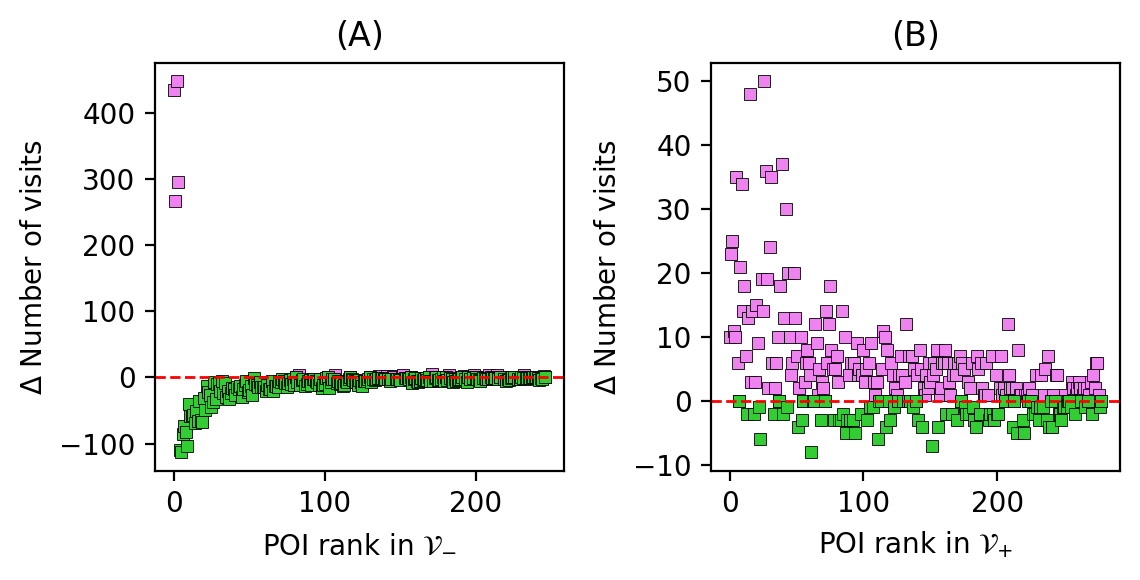

In [28]:
fig, (ax, bx) = plt.subplots(1,2, figsize=(5.8,3.0), sharey=0, layout="tight")

# >>>

lw = 0.7

mask = (shift_croi >= 0)
impr = (shift_croi <= 0)
croi_rank = np.arange(len(croi))

croi_data = shift_croi.copy()
croi_data[impr] = 0
ax.plot(croi_rank[mask], croi_data[mask], mec="k", mfc="violet", mew=0.3, lw=0, marker="s", ms=4)

croi_data = shift_croi.copy()
croi_data[mask] = 0
ax.plot(croi_rank[impr], croi_data[impr], mec="k", mfc="limegreen", mew=0.3, lw=0, marker="s", ms=4)

ax.axhline(y=0, color="r", ls="--", lw=1.0)
ax.minorticks_off()

ax.set_xlabel(r"POI rank in $\mathcal{V}_{-}$")
ax.set_ylabel(r"$\Delta$ Number of visits")

# >>>

mask = (shift_good >= 0)
impr = (shift_good <= 0)
good_rank = np.arange(len(good))

good_data = shift_good.copy()
good_data[impr] = 0
bx.plot(good_rank[mask], good_data[mask], mec="k", mfc="violet", mew=0.3, lw=0, marker="s", ms=4)

good_data = shift_good.copy()
good_data[mask] = 0
bx.plot(good_rank[impr], good_data[impr], mec="k", mfc="limegreen", mew=0.3, lw=0, marker="s", ms=4)

bx.axhline(y=0, color="r", ls="--", lw=1.0)
bx.minorticks_off()

bx.set_xlabel(r"POI rank in $\mathcal{V}_{+}$")
bx.set_ylabel(r"$\Delta$ Number of visits")

ax.set_title("(A)")
bx.set_title("(B)")

fig.savefig(f"policy.svg", dpi=300, pad_inches=0.1, bbox_inches="tight")
fig.show()